In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image, ImageEnhance
import cv2
from tqdm import tqdm
import datetime
import timm

import torch

DATA_PATH = "E:/ML/UBC"
print(DATA_PATH)


c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


E:/ML/UBC


In [2]:
timm.list_models("*edge*")

['cs3edgenet_x',
 'cs3se_edgenet_x',
 'edgenext_base',
 'edgenext_small',
 'edgenext_small_rw',
 'edgenext_x_small',
 'edgenext_xx_small']

In [3]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Dataset

In [4]:
trainList = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
trainList.head()

,image_id,label,image_width,image_height,is_tma
0,4,HGSC,23785,20008,False
1,66,LGSC,48871,48195,False
2,91,HGSC,3388,3388,True
3,281,LGSC,42309,15545,False
4,286,EC,37204,30020,False


In [5]:
from sklearn.preprocessing import LabelEncoder
import pickle

uniqueLabels = trainList["label"].unique()

enc = LabelEncoder()
# enc.fit(np.append(uniqueLabels, "Other"))
enc.fit(uniqueLabels)
print(enc.classes_)
print(enc.transform(["LGSC"]))

# with open('LabelEncoder.pkl', 'wb') as f:
#     pickle.dump(enc, f)

['CC' 'EC' 'HGSC' 'LGSC' 'MC']
[3]


In [6]:
print(f"{uniqueLabels=}")

uniqueLabels=array(['HGSC', 'LGSC', 'EC', 'CC', 'MC'], dtype=object)


In [7]:
allFiles = []


for root, dirs, files in os.walk(os.path.join(DATA_PATH, "trainProcessed/segPatches")):
    if not "non-cancerous" in root:
        for f in files:
            if f.endswith(".png") or f.endswith(".jpg") or f.endswith(".JPG") or f.endswith(".jpeg") or f.endswith(".tif") or f.endswith(".tiff"):
                allFiles.append(os.path.join(root, f))


    
len(allFiles)

16220

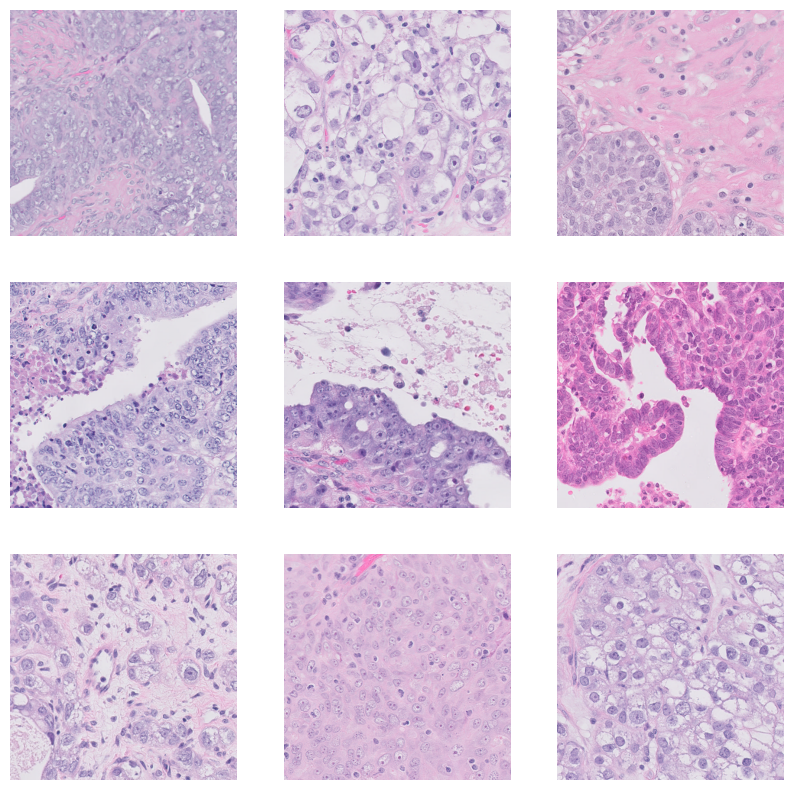

In [8]:

IMG_SIZE = (384, 384)
eps=1e-12

def readImage(path, skipResize=False):
    data = Image.open(path).convert("RGB")
        
    w, h = data.width, data.height

    #Center crop
    data = np.array(data)
    if w>h:
        diff = w-h
        data = data[diff//2:diff//2+h, :, :]
    if h>w:
        diff = h-w
        data = data[:, diff//2:diff//2+w, :]


    w, h, c = data.shape[0], data.shape[1], data.shape[2]

    # resize
    if not skipResize:
        if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
            data = np.array(Image.fromarray(data).resize(IMG_SIZE))
    
    # data = data/(np.max(data)+eps) * 2 - 1

    # data = (data * 255).astype(np.uint8)
    return data



plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(readImage(filePath))
    _ = plt.axis("off")
# plt.colorbar()

In [9]:
import pickle
trainListIndexed= trainList.set_index("image_id")

if os.path.exists(os.path.join(DATA_PATH,"./dataCancerous.pkl")):
    with open(os.path.join(DATA_PATH,"./dataCancerous.pkl"), "rb") as f:
        dictData = pickle.load(f)
        # XTrain, yTrain, XVal, yVal = dictData["XTrain"], dictData["yTrain"], dictData["XVal"], dictData["yVal"]
        X,y = dictData["X"], dictData["y"],
else:
    X=[]
    y=[]
    tma=[]
    for i,filePath in enumerate(tqdm(allFiles)):
        isTma = False
        if "patches" in filePath.lower():
            parts = filePath.split("\\")
            fileId = int(parts[-3])
            targets = trainListIndexed.loc[fileId]
            if targets["is_tma"]:
                isTma=True
            label = np.array([targets["label"]])
            encLabel = enc.transform(label)
        else:
            print("invalid folder")
            
        im = readImage(filePath, skipResize=True)
        # If most pixels are very bright or dark the patch is outside the relevant area
        # This is only relevant for the extracted patches
        if "patches" in filePath or "PKG-OBR" in filePath:
            hist , _ = np.histogram(im, bins=10, range=(0.0,255.0))
            if ((np.sum(hist[2:-2]))/(np.sum(hist)+eps)) < 0.1 or (hist[0])/np.sum(hist)>0.3:
                continue

     
        X.append(im)
        y.append(encLabel[0])
        tma.append(isTma)
    
            
    with open(os.path.join(DATA_PATH,"./dataCancerous.pkl"), "wb") as f:
        pickle.dump({"X":X, "y":y, "tma":tma}, f)

print(len(X))
print(X[0].shape)

16220
(512, 512, 3)


In [10]:
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ColorJitter(0.1, 0.1, 0.1, 0.05),
    # v2.Grayscale(3),
    # v2.RandomResizedCrop(IMG_SIZE, (0.2,0.6), (0.8,1.2)),
    v2.Resize(IMG_SIZE),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transformsVal = v2.Compose([
    # v2.Grayscale(3),
    v2.Resize(IMG_SIZE),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

TRAIN_TEST_SPLIT = 0.7

import random
random.seed(186)

split = int(len(X)*TRAIN_TEST_SPLIT)
print("# Training samples:",split)
dataShuffled = list(zip(X,y))
random.shuffle(dataShuffled)
# trainData = list(zip(XTrain,yTrain))
# random.shuffle(trainData)
# valData = list(zip(XVal,yVal))
# random.shuffle(valData)

trainData = dataShuffled[0:split]
valData = dataShuffled[split::]


def generator():
    for im, label in trainData:
        im = np.swapaxes(np.array(im), 0,-1).astype(np.float32)/255.0
        im = transforms(torch.Tensor(im))
        yield im, label.astype(np.int64)


def generatorVal():
    for imVal, labelVal in valData:
        imVal = np.swapaxes(np.array(imVal), 0,-1).astype(np.float32)/255.0
        imVal = transformsVal(torch.Tensor(imVal))
        yield imVal, labelVal.astype(np.int64)

# def generatorAll():
#     for id in allIds:
#         yield getData(id)

# Training samples: 11354


c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchvision\transforms\v2\__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you m

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


tensor(-1.4063) tensor(2.6163)
torch.Size([3, 384, 384])
1


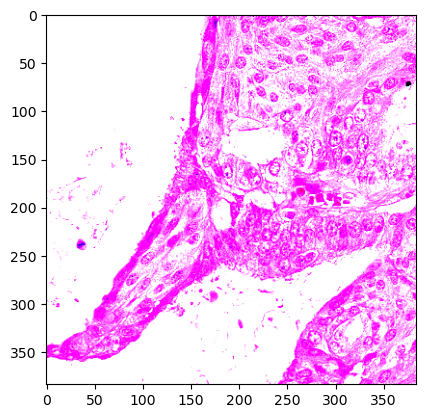

In [11]:
g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)

plt.imshow(torch.moveaxis(testInstance[0], 0,-1))
print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])

In [12]:
BATCH_SIZE = 32

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(trainData))
datasetVal = IterDataset(generatorVal, len(valData))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
for XData, targets in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    break

Shape of X: torch.Size([32, 3, 384, 384]) torch.float32
Max and Min:  tensor(2.6400) tensor(-1.7802)
Shape of target: torch.Size([32]) torch.int64


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


tensor(3)


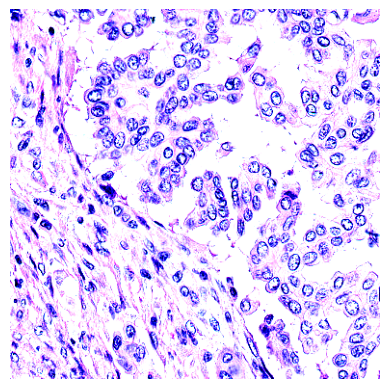

In [14]:
idx=2
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(torch.moveaxis(XData, 1,-1)[idx,:,:,:])
_=plt.axis("off")

## Pytorch Model

In [15]:
from torch import nn
import torchinfo
from torch import nn
import torch
from modelZoo.models import Res2DModel, ResNet2DModel, ResNet34

Dropout=0.05
HIDDEN_DIM=512
K=2

    
# model = Res2DModel(len(enc.classes_), channels=3, name="Res2DModelPatches_K_{}".format(K), K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useSoftmax=False)
# model = ResNet2DModel(len(enc.classes_), inputDim=IMG_SIZE[0], channels=3, name="ResNet2DModelPatches_K_{}".format(K), K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useSoftmax=False, useGAP=True)
# model = ResNet34(len(enc.classes_), inputDim=IMG_SIZE[0], channels=3, name="ResNet34Patches", K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useSoftmax=False, useGAP=True)

model = timm.create_model('resnet34d', pretrained=True, num_classes=len(enc.classes_))
model.name = f"seg_resnet34d_{IMG_SIZE[0]}_{len(enc.classes_)}"

# model = timm.create_model('resnet34d', pretrained=True, num_classes=len(enc.classes_))
# model.name = "resnet34d_384_wang"

# model = timm.create_model('rexnet_150', pretrained=True, num_classes=len(enc.classes_))
# model.name = "RexNet150"

from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)

model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 5]                   --
├─Sequential: 1-1                        [32, 64, 192, 192]        --
│    └─Conv2d: 2-1                       [32, 32, 192, 192]        864
│    └─BatchNorm2d: 2-2                  [32, 32, 192, 192]        64
│    └─ReLU: 2-3                         [32, 32, 192, 192]        --
│    └─Conv2d: 2-4                       [32, 32, 192, 192]        9,216
│    └─BatchNorm2d: 2-5                  [32, 32, 192, 192]        64
│    └─ReLU: 2-6                         [32, 32, 192, 192]        --
│    └─Conv2d: 2-7                       [32, 64, 192, 192]        18,432
├─BatchNorm2d: 1-2                       [32, 64, 192, 192]        128
├─ReLU: 1-3                              [32, 64, 192, 192]        --
├─MaxPool2d: 1-4                         [32, 64, 96, 96]          --
├─Sequential: 1-5                        [32, 64, 96, 96]          --
│    └

In [16]:
# model_graph.visual_graph

In [17]:
loadExistingModel=False

if loadExistingModel:
    model = model.to(device)
    checkpoint = torch.load(os.path.join("./", "edgenextBase_384_epoch_8.pt"), map_location=device)
    print(model.load_state_dict(checkpoint['model_state_dict']))
    optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=len(trainLoader), epochs=10)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.01)/100))
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    startEpoch = checkpoint['epoch']
    # startEpoch=0
    # loss = checkpoint['loss']
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(trainLoader), epochs=15)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.1)/500))

In [18]:
from utils import BalancedAccuracy, FocalLoss

testF = FocalLoss()
print(testF(torch.Tensor([[-10,4,-2], [-10,0,-2]]), torch.Tensor([1,1]).type(dtype=torch.int64)))



tensor(0.0007)


c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchaudio\backend\utils.py:74: UserWarning: No audio backend is available.
  warnings.warn("No audio backend is available.")


In [19]:
from torcheval import metrics
from torch.utils.tensorboard import SummaryWriter
from torchmetrics import AUROC, Accuracy, Recall


LOG_INTERVAL=5
epochs = 100
EARLY_STOPPING_PATIENCE=4
saveModel=False


log_dir = "./logs/"+model.name+"/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter(log_dir)

# Instantiate an optimizer .
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Instantiate a loss function.
# lossFn = torch.nn.CrossEntropyLoss()
lossFn = FocalLoss()


accMetric = Recall(task="multiclass", num_classes=len(enc.classes_), average="macro").to(device)
aurocMetric = AUROC(task="multiclass", num_classes=len(enc.classes_)).to(device)
# f1Metric = tf.keras.metrics.F1Score(threshold=0.5, average="micro")

accMetricVal = Recall(task="multiclass", num_classes=len(enc.classes_), average=None).to(device)

# optimizer = torch.optim.SGD(model.parameters(), lr=0.004, momentum=0.9)

def train(dataloaderTrain, model, optimizer, epoch):
    size = len(dataloaderTrain.dataset)
    model.train()
    for batch, (XTrain, yTrain) in enumerate(dataloaderTrain):
        # XTrain = XTrain.movedim(-1,1)
        XTrain, yTrain = XTrain.to(device), yTrain.to(device)
        pred = model(XTrain)
        # targetLabel = torch.argmax(y, dim=1)
        
        loss = lossFn(pred, yTrain)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # scheduler.step()

        accMetric.update(pred, yTrain)
        aurocMetric.update(pred, yTrain)
        
        if batch % LOG_INTERVAL == 0:
            print("loss: {:>5f}, acc: {:.4f}, AUROC: {:.4f}  [{:>5d}/{:>5d}]".format(loss.item(), accMetric.compute(),  aurocMetric.compute(), batch*BATCH_SIZE, size))
            summary_writer.add_scalar("Loss", loss.item(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Acc", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("AUROC", aurocMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()



def validate(dataloaderVal, model, epoch):
    print("Start Validation...")
    model.eval()
    loss = 0
    for batch, (XVal, yVal) in enumerate(dataloaderVal):
        # XVal = XVal.movedim(-1,1)
        XVal, yVal = XVal.to(device), yVal.to(device)
        predVal = model(XVal)
        accMetricVal.update(predVal, yVal)
        

    print("Accuracy: {:>7f}".format(torch.mean(accMetricVal.compute())))
    summary_writer.add_scalar("Val Accuracy", torch.mean(accMetricVal.compute()), epoch)
    summary_writer.flush()
    fig, ax = accMetricVal.plot()
    fig.savefig(os.path.join(DATA_PATH, "metricPlots", "accuracy_{}.png".format(epoch)))
    plt.close()
    return torch.mean(accMetricVal.compute())


bestValAcc=0.0
bestEpoch=0

for t in np.arange(startEpoch, startEpoch+epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    train(trainLoader, model, optimizer, t)
    accMetric.reset()
    aurocMetric.reset()

    avgAccVal = validate(valLoader, model, t)
    accMetricVal.reset()
    
    #Early stopping
    if avgAccVal > bestValAcc:
        bestValAcc = avgAccVal
        bestEpoch = t
        bestWeights = model.state_dict()
    if t - bestEpoch >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break

    print("LR: {:.2E}".format(optimizer.state_dict()["param_groups"][0]["lr"]))
    
print("Done!")
print("Best Val Acc: ", bestValAcc.detach().cpu().numpy())

Epoch 1
-------------------------------
loss: 0.885419, acc: 0.1000, AUROC: 0.4890  [    0/11354]
loss: 0.792994, acc: 0.2248, AUROC: 0.6352  [  160/11354]
loss: 0.712654, acc: 0.3059, AUROC: 0.6655  [  320/11354]
loss: 0.604151, acc: 0.3481, AUROC: 0.7146  [  480/11354]
loss: 0.566435, acc: 0.3889, AUROC: 0.7446  [  640/11354]
loss: 0.458141, acc: 0.4351, AUROC: 0.7742  [  800/11354]
loss: 0.456782, acc: 0.4526, AUROC: 0.7851  [  960/11354]
loss: 0.492160, acc: 0.4717, AUROC: 0.7938  [ 1120/11354]
loss: 0.494536, acc: 0.4889, AUROC: 0.8069  [ 1280/11354]
loss: 0.376231, acc: 0.5037, AUROC: 0.8151  [ 1440/11354]
loss: 0.365702, acc: 0.5178, AUROC: 0.8254  [ 1600/11354]
loss: 0.261635, acc: 0.5311, AUROC: 0.8337  [ 1760/11354]
loss: 0.342335, acc: 0.5433, AUROC: 0.8416  [ 1920/11354]
loss: 0.292009, acc: 0.5466, AUROC: 0.8435  [ 2080/11354]
loss: 0.355080, acc: 0.5594, AUROC: 0.8523  [ 2240/11354]
loss: 0.280542, acc: 0.5675, AUROC: 0.8585  [ 2400/11354]
loss: 0.240816, acc: 0.5749, AUR

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


loss: 0.123800, acc: 0.8683, AUROC: 0.9902  [    0/11354]
loss: 0.060576, acc: 0.8858, AUROC: 0.9867  [  160/11354]
loss: 0.076648, acc: 0.8653, AUROC: 0.9845  [  320/11354]
loss: 0.059619, acc: 0.8761, AUROC: 0.9836  [  480/11354]
loss: 0.156931, acc: 0.8849, AUROC: 0.9840  [  640/11354]
loss: 0.057661, acc: 0.8859, AUROC: 0.9836  [  800/11354]
loss: 0.139681, acc: 0.8826, AUROC: 0.9832  [  960/11354]
loss: 0.073234, acc: 0.8805, AUROC: 0.9834  [ 1120/11354]
loss: 0.043712, acc: 0.8777, AUROC: 0.9836  [ 1280/11354]
loss: 0.120774, acc: 0.8753, AUROC: 0.9839  [ 1440/11354]
loss: 0.102340, acc: 0.8814, AUROC: 0.9852  [ 1600/11354]
loss: 0.037063, acc: 0.8821, AUROC: 0.9853  [ 1760/11354]
loss: 0.123133, acc: 0.8775, AUROC: 0.9850  [ 1920/11354]
loss: 0.187143, acc: 0.8720, AUROC: 0.9839  [ 2080/11354]
loss: 0.120806, acc: 0.8751, AUROC: 0.9843  [ 2240/11354]
loss: 0.072520, acc: 0.8760, AUROC: 0.9846  [ 2400/11354]
loss: 0.064618, acc: 0.8752, AUROC: 0.9849  [ 2560/11354]
loss: 0.088409

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


loss: 0.080826, acc: 0.8683, AUROC: 0.9962  [    0/11354]
loss: 0.066622, acc: 0.8959, AUROC: 0.9946  [  160/11354]
loss: 0.073084, acc: 0.9037, AUROC: 0.9935  [  320/11354]
loss: 0.010188, acc: 0.9208, AUROC: 0.9947  [  480/11354]
loss: 0.096648, acc: 0.9254, AUROC: 0.9938  [  640/11354]
loss: 0.053992, acc: 0.9240, AUROC: 0.9943  [  800/11354]
loss: 0.091352, acc: 0.9230, AUROC: 0.9936  [  960/11354]
loss: 0.021427, acc: 0.9207, AUROC: 0.9935  [ 1120/11354]
loss: 0.018589, acc: 0.9223, AUROC: 0.9936  [ 1280/11354]
loss: 0.025636, acc: 0.9234, AUROC: 0.9936  [ 1440/11354]
loss: 0.077183, acc: 0.9268, AUROC: 0.9939  [ 1600/11354]
loss: 0.048658, acc: 0.9255, AUROC: 0.9939  [ 1760/11354]
loss: 0.032590, acc: 0.9251, AUROC: 0.9936  [ 1920/11354]
loss: 0.047536, acc: 0.9208, AUROC: 0.9929  [ 2080/11354]
loss: 0.103598, acc: 0.9217, AUROC: 0.9930  [ 2240/11354]
loss: 0.050207, acc: 0.9239, AUROC: 0.9933  [ 2400/11354]
loss: 0.096942, acc: 0.9228, AUROC: 0.9932  [ 2560/11354]
loss: 0.092593

...

loss: 0.023481, acc: 0.9600, AUROC: 1.0000  [    0/11354]
loss: 0.008370, acc: 0.9701, AUROC: 0.9996  [  160/11354]
loss: 0.043195, acc: 0.9710, AUROC: 0.9991  [  320/11354]
loss: 0.002561, acc: 0.9668, AUROC: 0.9993  [  480/11354]
loss: 0.067791, acc: 0.9650, AUROC: 0.9987  [  640/11354]
loss: 0.051030, acc: 0.9668, AUROC: 0.9985  [  800/11354]
loss: 0.022249, acc: 0.9662, AUROC: 0.9985  [  960/11354]
loss: 0.010311, acc: 0.9643, AUROC: 0.9982  [ 1120/11354]
loss: 0.003696, acc: 0.9646, AUROC: 0.9982  [ 1280/11354]
loss: 0.023862, acc: 0.9645, AUROC: 0.9983  [ 1440/11354]
loss: 0.011520, acc: 0.9654, AUROC: 0.9984  [ 1600/11354]
loss: 0.017744, acc: 0.9657, AUROC: 0.9984  [ 1760/11354]
loss: 0.028842, acc: 0.9659, AUROC: 0.9983  [ 1920/11354]
loss: 0.012633, acc: 0.9658, AUROC: 0.9983  [ 2080/11354]
loss: 0.025412, acc: 0.9672, AUROC: 0.9983  [ 2240/11354]
loss: 0.012698, acc: 0.9680, AUROC: 0.9984  [ 2400/11354]
loss: 0.004677, acc: 0.9693, AUROC: 0.9985  [ 2560/11354]
loss: 0.004558

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


loss: 0.003458, acc: 1.0000, AUROC: 1.0000  [    0/11354]
loss: 0.071519, acc: 0.9654, AUROC: 0.9988  [  160/11354]
loss: 0.017975, acc: 0.9667, AUROC: 0.9980  [  320/11354]
loss: 0.011420, acc: 0.9739, AUROC: 0.9986  [  480/11354]
loss: 0.016602, acc: 0.9746, AUROC: 0.9988  [  640/11354]
loss: 0.017435, acc: 0.9743, AUROC: 0.9987  [  800/11354]
loss: 0.050624, acc: 0.9715, AUROC: 0.9985  [  960/11354]
loss: 0.003266, acc: 0.9716, AUROC: 0.9986  [ 1120/11354]
loss: 0.005103, acc: 0.9703, AUROC: 0.9986  [ 1280/11354]
loss: 0.027431, acc: 0.9709, AUROC: 0.9987  [ 1440/11354]
loss: 0.036804, acc: 0.9708, AUROC: 0.9987  [ 1600/11354]
loss: 0.005024, acc: 0.9715, AUROC: 0.9988  [ 1760/11354]
loss: 0.003946, acc: 0.9716, AUROC: 0.9988  [ 1920/11354]
loss: 0.060621, acc: 0.9692, AUROC: 0.9987  [ 2080/11354]
loss: 0.032263, acc: 0.9702, AUROC: 0.9987  [ 2240/11354]
loss: 0.005787, acc: 0.9716, AUROC: 0.9988  [ 2400/11354]
loss: 0.003370, acc: 0.9713, AUROC: 0.9988  [ 2560/11354]
loss: 0.004403

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


loss: 0.000788, acc: 1.0000, AUROC: 1.0000  [    0/11354]
loss: 0.007748, acc: 1.0000, AUROC: 1.0000  [  160/11354]
loss: 0.003550, acc: 0.9893, AUROC: 1.0000  [  320/11354]
loss: 0.013171, acc: 0.9886, AUROC: 0.9999  [  480/11354]
loss: 0.026518, acc: 0.9898, AUROC: 0.9999  [  640/11354]
loss: 0.013063, acc: 0.9900, AUROC: 0.9999  [  800/11354]
loss: 0.009326, acc: 0.9885, AUROC: 0.9999  [  960/11354]
loss: 0.001535, acc: 0.9861, AUROC: 0.9999  [ 1120/11354]
loss: 0.001944, acc: 0.9861, AUROC: 0.9998  [ 1280/11354]
loss: 0.013984, acc: 0.9850, AUROC: 0.9998  [ 1440/11354]
loss: 0.017402, acc: 0.9830, AUROC: 0.9997  [ 1600/11354]
loss: 0.004531, acc: 0.9833, AUROC: 0.9996  [ 1760/11354]
loss: 0.014025, acc: 0.9834, AUROC: 0.9997  [ 1920/11354]
loss: 0.013629, acc: 0.9824, AUROC: 0.9996  [ 2080/11354]
loss: 0.030537, acc: 0.9819, AUROC: 0.9996  [ 2240/11354]
loss: 0.020659, acc: 0.9811, AUROC: 0.9996  [ 2400/11354]
loss: 0.002480, acc: 0.9809, AUROC: 0.9996  [ 2560/11354]
loss: 0.006354

In [22]:
bestValAcc= bestValAcc.detach().cpu().numpy()
print(bestValAcc)
model.load_state_dict(bestWeights)

0.77909917


<All keys matched successfully>

In [23]:
torch.save({
    'epoch': t,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    # 'scheduler_state_dict': scheduler.state_dict(),
    # 'loss': loss,
    }, os.path.join("./", f"{model.name}_epoch_{bestEpoch}_ValAcc_{bestValAcc:.4f}.pt"))

In [20]:
model_scripted = torch.jit.script(model) # Export to TorchScript
model_scripted.save('{}_scripted.pt'.format(model.name)) # Save

# modelCPU = model.to("cpu")
# modelCPU_scripted = torch.jit.script(modelCPU) # Export to TorchScript
# modelCPU_scripted.save('{}_scriptedCPU.pt'.format(model.name)) # Save

### Testing

(array([2912., 3793., 6315., 1334., 1292.]),
 array([0. , 0.8, 1.6, 2.4, 3.2, 4. ]),
 <BarContainer object of 5 artists>)

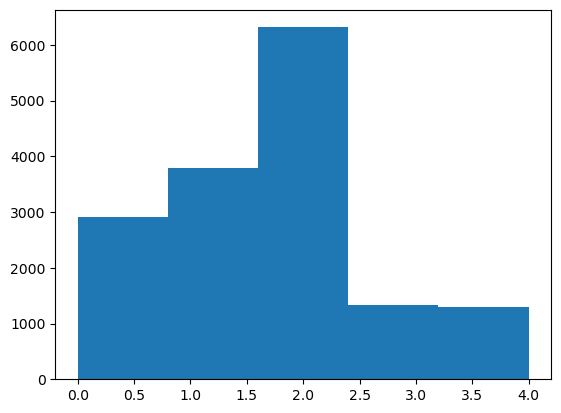

In [47]:
plt.hist(y, bins=len(enc.classes_)-1)

In [48]:
enc.classes_

array(['CC', 'EC', 'HGSC', 'LGSC', 'MC', 'Other'], dtype=object)

In [49]:
for i,(XTest,yTest) in enumerate(trainLoader):
    if i == 2:
        break

XTest = torch.moveaxis(XTest, 1,-1)

IndexError: index 16 is out of bounds for dimension 0 with size 16

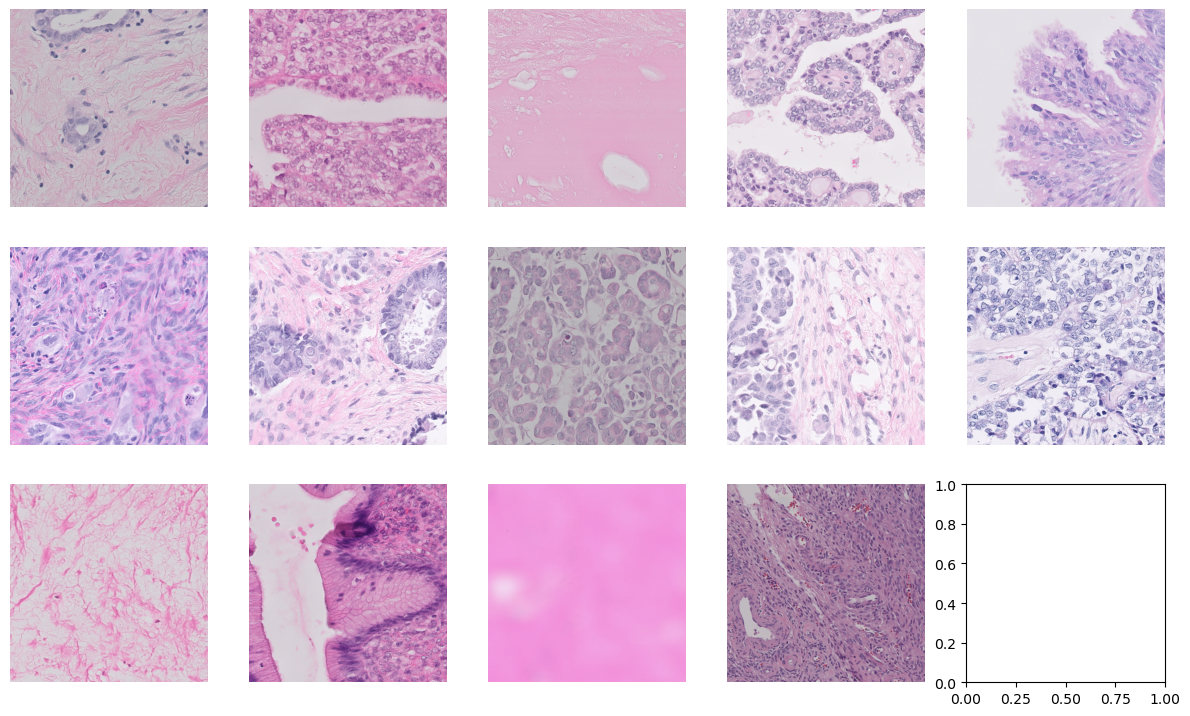

In [50]:
plt.figure(figsize=(18,18))

for i in range(5):
    for j in range(5):
        plt.subplot(6,6,i*6+j+1)
        plt.imshow(XTest[i*6+j,:,:,:])
        _=plt.axis("off")

0.0
0.5217104311342593
0.19331868489583334


array([     0,      0,      0,    118,   1237,   6753,  22180,  55230,
       126062, 230788], dtype=int64)

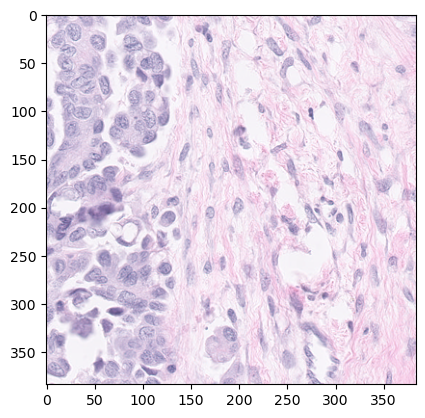

In [51]:
idx = 9
hist , _ = np.histogram(XTest[idx,:,:,:], bins=10, range=(0.0,1.0))
plt.imshow(XTest[idx,:,:,:])
print((hist[0])/np.sum(hist))
print((hist[0] + hist[-1])/np.sum(hist))
print((np.sum(hist[2:-2]))/np.sum(hist))
hist